In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.transforms import blended_transform_factory

C_CM = 1e7  # nm * cm^-1


# 0-0 Q branch from your table (cm^-1)
BH_Q_LINES = {
     1: 23074.117,
     2: 23074.414,
     3: 23074.791,
     4: 23075.320,
     5: 23075.933,
     6: 23076.609,
     7: 23077.358,
     8: 23078.040,
     9: 23078.716,
    10: 23079.297,
    11: 23079.714,
    12: 23079.931,
    13: 23079.841,
    14: 23079.371,
    15: 23078.412,
    16: 23076.867,
    17: 23074.636,
    18: 23071.523,
    19: 23067.380,
    20: 23062.041,
    21: 23055.280,
    22: 23046.834,
    23: 23036.414,
    24: 23023.721,
    25: 23008.278,
}


def wavenumber_to_nm(nu_cm):
    return C_CM / nu_cm


def add_q_branch_gauge(
    ax,
    lines=BH_Q_LINES,
    y=0.92,
    tick_height=0.04,
    fontsize=10,
    color="k",
    x_offset_nm=0.0,
    label_J=None,
):
    from matplotlib.transforms import blended_transform_factory

    trans = blended_transform_factory(ax.transData, ax.transAxes)

    for J, nu in lines.items():

        wl = wavenumber_to_nm(nu) + x_offset_nm

        ax.plot(
            [wl, wl],
            [y, y + tick_height],
            color=color,
            lw=1.2,
            transform=trans,
            clip_on=False,
        )

        if label_J is None or J in label_J:

            # stagger crowded labels slightly
            dy = 0.05 if J % 2 == 0 else 0.0

            ax.text(
                wl,
                y + tick_height + 0.01 + dy,
                f"{J}",
                ha="center",
                va="bottom",
                fontsize=fontsize,
                transform=trans,
                clip_on=False,
            )

    ax.text(
        np.mean([wavenumber_to_nm(v) for v in lines.values()]),
        y - 0.03,
        "0-0 Q",
        ha="center",
        va="top",
        fontsize=fontsize + 1,
        transform=trans,
    )

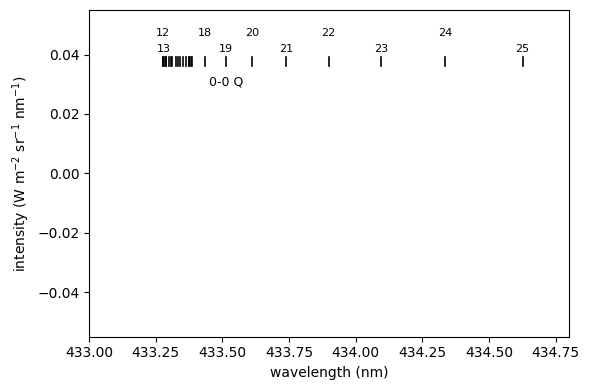

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.set_xlim(433.0, 434.8)

add_q_branch_gauge(
    ax,
    y=0.83,
    tick_height=0.025,
    fontsize=8,

    # only label sparse lines
    label_J=[12, 13, 18, 19, 20, 21, 22, 23, 24, 25],
)

ax.set_xlabel("wavelength (nm)")
ax.set_ylabel(r"intensity (W m$^{-2}$ sr$^{-1}$ nm$^{-1}$)")

plt.tight_layout()